# 02 — Nettoyage et Fusion des Datasets

**Projet :** Heatwave-ML  
**Objectif :** Nettoyer les deux sources de données météo, les fusionner `is_heatwave`

---

## Pipeline général

```
Partie 1 — Chargement des bibliothèques
Partie 2 — Nettoyage city_temperature.csv
Partie 3 — Nettoyage Open-Meteo
Partie 4 — Fusion des deux datasets
Partie 5 — Sauvegarde du dataset final
```

## Partie 1 — Chargement des bibliothèques





In [ ]:

# ── Partie 1 — Imports & Configuration ──────────────────────

from google.colab import drive
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os


In [ ]:
# ── Configuration du projet ───────────────────────────────────
PROJECT_ROOT = "/content/drive/MyDrive/heatwave-ml"

drive.mount('/content/drive')
os.chdir(PROJECT_ROOT)
print(f" Répertoire courant : {os.getcwd()}")

In [ ]:
# ── Création des dossiers de sortie
for folder in ["data/processed", "data/plots", "figures"]:
    os.makedirs(folder, exist_ok=True)

print("Dossiers créés : data/processed | data/plots | figures")

# ── Vérification des fichiers sources
print("\n Fichiers dans data/raw :")
for f in os.listdir("data/raw"):
    print(f"   - {f}")

In [ ]:
drive.mount('/content/drive')
PROJECT_ROOT = "/content/drive/MyDrive/heatwave-ml"
os.chdir(PROJECT_ROOT)

for folder in ['data/raw', 'data/processed', 'figures']:
    os.makedirs(folder, exist_ok=True)

print(f"✅ Setup terminé — Répertoire : {os.getcwd()}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Setup terminé — Répertoire : /content/drive/MyDrive/heatwave-ml


In [ ]:
# ── Chargement des datasets ──────────────────────────────────

df_temp      = pd.read_csv("data/raw/city_temperature.csv")
df_openmeteo = pd.read_parquet("data/processed/openmeteo_final.parquet")

print(f"city_temperature : {df_temp.shape[0]:,} lignes × {df_temp.shape[1]} cols")
print(f"Open-Meteo       : {df_openmeteo.shape[0]:,} lignes × {df_openmeteo.shape[1]} cols")


/tmp/ipykernel_14418/3570686278.py:3: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df_temp      = pd.read_csv("data/raw/city_temperature.csv")


city_temperature : 2,906,327 lignes × 8 cols
Open-Meteo       : 421,890 lignes × 10 cols


##Partie 2 — Nettoyage city_temperature.csv


In [ ]:

print(f"\nShape initiale df_temp : {df_temp.shape}")

# ÉTAPE 1 : Suppression des colonnes inutiles
df_temp = df_temp.drop(columns=['State'])
print(f"Après suppression State : {df_temp.shape}")


Shape initiale df_temp : (2906327, 8)
Après suppression State : (2906327, 7)


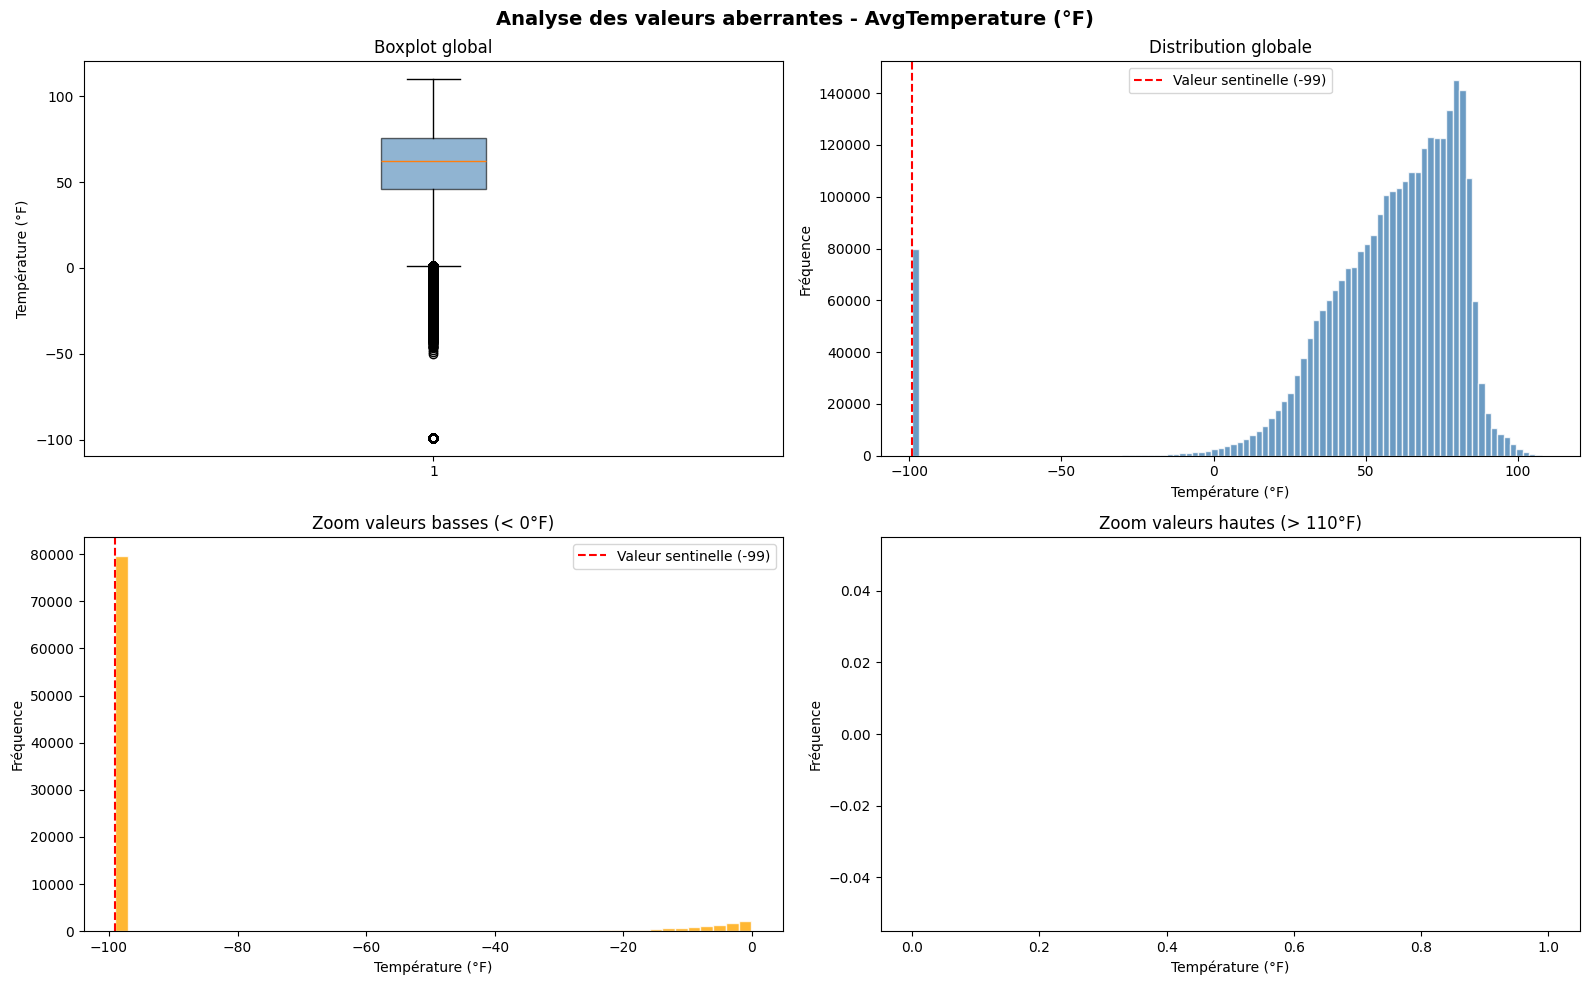

In [ ]:


# ÉTAPE 2 : Visualisation des valeurs aberrantes

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Analyse des valeurs aberrantes - AvgTemperature (°F)', fontsize=14, fontweight='bold')

axes[0, 0].boxplot(df_temp['AvgTemperature'].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[0, 0].set_title('Boxplot global')
axes[0, 0].set_ylabel('Température (°F)')

axes[0, 1].hist(df_temp['AvgTemperature'].dropna(), bins=100,
                color='steelblue', edgecolor='white', alpha=0.8)
axes[0, 1].axvline(-99, color='red', linestyle='--', label='Valeur sentinelle (-99)')
axes[0, 1].set_title('Distribution globale')
axes[0, 1].set_xlabel('Température (°F)')
axes[0, 1].set_ylabel('Fréquence')
axes[0, 1].legend()

axes[1, 0].hist(df_temp[df_temp['AvgTemperature'] < 0]['AvgTemperature'],
                bins=50, color='orange', edgecolor='white', alpha=0.8)
axes[1, 0].axvline(-99, color='red', linestyle='--', label='Valeur sentinelle (-99)')
axes[1, 0].set_title('Zoom valeurs basses (< 0°F)')
axes[1, 0].set_xlabel('Température (°F)')
axes[1, 0].set_ylabel('Fréquence')
axes[1, 0].legend()

axes[1, 1].hist(df_temp[df_temp['AvgTemperature'] > 110]['AvgTemperature'],
                bins=50, color='tomato', edgecolor='white', alpha=0.8)
axes[1, 1].set_title('Zoom valeurs hautes (> 110°F)')
axes[1, 1].set_xlabel('Température (°F)')
axes[1, 1].set_ylabel('Fréquence')

plt.tight_layout()
plt.savefig('figures/01_outliers_temp.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ÉTAPE 3 : Statistiques des anomalies

print("\n" + "=" * 50)
print("STATISTIQUES DESCRIPTIVES")
print("=" * 50)
print(df_temp['AvgTemperature'].describe())

print("\n" + "=" * 50)
print("COMPTAGE DES ANOMALIES")
print("=" * 50)
print(f"Valeurs == -99   : {(df_temp['AvgTemperature'] == -99).sum():,}")
print(f"Valeurs < -60°F  : {(df_temp['AvgTemperature'] < -60).sum():,}")
print(f"Valeurs > 130°F  : {(df_temp['AvgTemperature'] > 130).sum():,}")


STATISTIQUES DESCRIPTIVES
count    2.906327e+06
mean     5.600492e+01
std      3.212359e+01
min     -9.900000e+01
25%      4.580000e+01
50%      6.250000e+01
75%      7.550000e+01
max      1.100000e+02
Name: AvgTemperature, dtype: float64

COMPTAGE DES ANOMALIES
Valeurs == -99   : 79,672
Valeurs < -60°F  : 79,672
Valeurs > 130°F  : 0


In [ ]:

# ÉTAPE 4 : Suppression des valeurs aberrantes

lignes_avant = len(df_temp)
df_temp = df_temp[
    (df_temp['AvgTemperature'] != -99) &
    (df_temp['AvgTemperature'] >= -60) &
    (df_temp['AvgTemperature'] <= 130)
]
print(f"\nLignes supprimées (outliers) : {lignes_avant - len(df_temp):,}")
print(f"Shape après outliers : {df_temp.shape}")



Lignes supprimées (outliers) : 79,672
Shape après outliers : (2826655, 7)


In [ ]:
# ÉTAPE 5 : Conversion °F → °C

df_temp['AvgTemperature_C'] = (df_temp['AvgTemperature'] - 32) * 5 / 9
df_temp = df_temp.drop(columns=['AvgTemperature'])
print(f"\nConversion °F → °C effectuée")



Conversion °F → °C effectuée


In [ ]:

# ÉTAPE 6 : Suppression des doublons

lignes_avant = len(df_temp)
df_temp = df_temp.drop_duplicates()
print(f"Doublons supprimés : {lignes_avant - len(df_temp):,}")

Doublons supprimés : 20,418


In [ ]:
# ÉTAPE 7 : Création de la colonne date

df_temp['date'] = pd.to_datetime(df_temp[['Year', 'Month', 'Day']])
df_temp = df_temp.drop(columns=['Year', 'Month', 'Day'])
print(f"Colonne date créée")

Colonne date créée


In [ ]:
# ÉTAPE 8 : Harmonisation des noms de villes

df_temp['City_clean'] = df_temp['City'].str.strip().str.title()
df_temp = df_temp.drop(columns=['City'])

print("\n" + "=" * 50)
print("RÉSUMÉ FINAL df_temp")
print("=" * 50)
print(f"Shape finale  : {df_temp.shape}")
print(f"Colonnes      : {list(df_temp.columns)}")
print(f"\nValeurs manquantes :\n{df_temp.isnull().sum()}")
print(f"\n{df_temp.head()}")


RÉSUMÉ FINAL df_temp
Shape finale  : (2806237, 5)
Colonnes      : ['Region', 'Country', 'AvgTemperature_C', 'date', 'City_clean']

Valeurs manquantes :
Region              0
Country             0
AvgTemperature_C    0
date                0
City_clean          0
dtype: int64

   Region  Country  AvgTemperature_C       date City_clean
0  Africa  Algeria         17.888889 1995-01-01    Algiers
1  Africa  Algeria          9.666667 1995-01-02    Algiers
2  Africa  Algeria          9.333333 1995-01-03    Algiers
3  Africa  Algeria          8.000000 1995-01-04    Algiers
4  Africa  Algeria          8.833333 1995-01-05    Algiers


##Partie 3 — Nettoyage Open-Meteo


In [ ]:


print(f"\nShape initiale df_openmeteo : {df_openmeteo.shape}")
print(f"Colonnes : {list(df_openmeteo.columns)}")


Shape initiale df_openmeteo : (421890, 10)
Colonnes : ['date', 'temp_max', 'temp_min', 'temp_mean', 'heat_index', 'humidity', 'precip_mm', 'wind_kph', 'uv_index', 'City_clean']


In [ ]:
# ÉTAPE 1 : Vérification uv_index

print("\n" + "=" * 50)
print("VÉRIFICATION uv_index")
print("=" * 50)
if 'uv_index' in df_openmeteo.columns:
    uv_null_pct = df_openmeteo['uv_index'].isnull().sum() / len(df_openmeteo) * 100
    print(f"% NaN uv_index : {uv_null_pct:.2f}%")
    if uv_null_pct == 100:
        df_openmeteo = df_openmeteo.drop(columns=['uv_index'])
        print("→ uv_index supprimée (100% NaN)")
else:
    print("→ uv_index déjà supprimée, on continue")


VÉRIFICATION uv_index
% NaN uv_index : 100.00%
→ uv_index supprimée (100% NaN)


In [ ]:
# ÉTAPE 2 : Suppression des doublons

print("\n" + "=" * 50)
print("SUPPRESSION DES DOUBLONS")
print("=" * 50)
lignes_avant = len(df_openmeteo)
df_openmeteo = df_openmeteo.drop_duplicates()
print(f"Doublons supprimés : {lignes_avant - len(df_openmeteo):,}")
print(f"Shape après doublons : {df_openmeteo.shape}")



SUPPRESSION DES DOUBLONS
Doublons supprimés : 0
Shape après doublons : (421890, 9)


In [ ]:
# ÉTAPE 3 : Analyse toutes colonnes numériques

print("\n" + "=" * 50)
print("ANALYSE OUTLIERS - toutes colonnes numériques")
print("=" * 50)
cols_numeriques = ['temp_max', 'temp_min', 'temp_mean', 'heat_index', 'humidity', 'precip_mm', 'wind_kph']
print(df_openmeteo[cols_numeriques].describe())

print(f"\nhumidity < 0    : {(df_openmeteo['humidity'] < 0).sum()}")
print(f"humidity > 100  : {(df_openmeteo['humidity'] > 100).sum()}")
print(f"precip_mm < 0   : {(df_openmeteo['precip_mm'] < 0).sum()}")
print(f"wind_kph < 0    : {(df_openmeteo['wind_kph'] < 0).sum()}")
print(f"wind_kph > 150  : {(df_openmeteo['wind_kph'] > 150).sum()}")
print(df_openmeteo[df_openmeteo['wind_kph'] > 150][['date', 'City_clean', 'wind_kph']]
      .sort_values('wind_kph', ascending=False))


ANALYSE OUTLIERS - toutes colonnes numériques
            temp_max       temp_min      temp_mean     heat_index  \
count  421890.000000  421890.000000  421890.000000  421890.000000   
mean       22.792011      14.743846      18.521072      23.262789   
std         9.571755       9.332286       9.229929      12.201175   
min       -26.250000     -34.193501     -28.520836     -32.327015   
25%        17.200001       8.775500      12.872999      15.462228   
50%        25.200001      16.100000      20.444331      25.923095   
75%        29.500000      22.952501      25.955919      33.100779   
max        49.799999      38.049999      42.781250      49.609306   

            humidity      precip_mm       wind_kph  
count  421890.000000  421890.000000  421890.000000  
mean       71.308670       2.801495      16.512932  
std        16.526613       6.897525       7.054396  
min         3.769842       0.000000       2.276840  
25%        63.064802       0.000000      11.298495  
50%        75

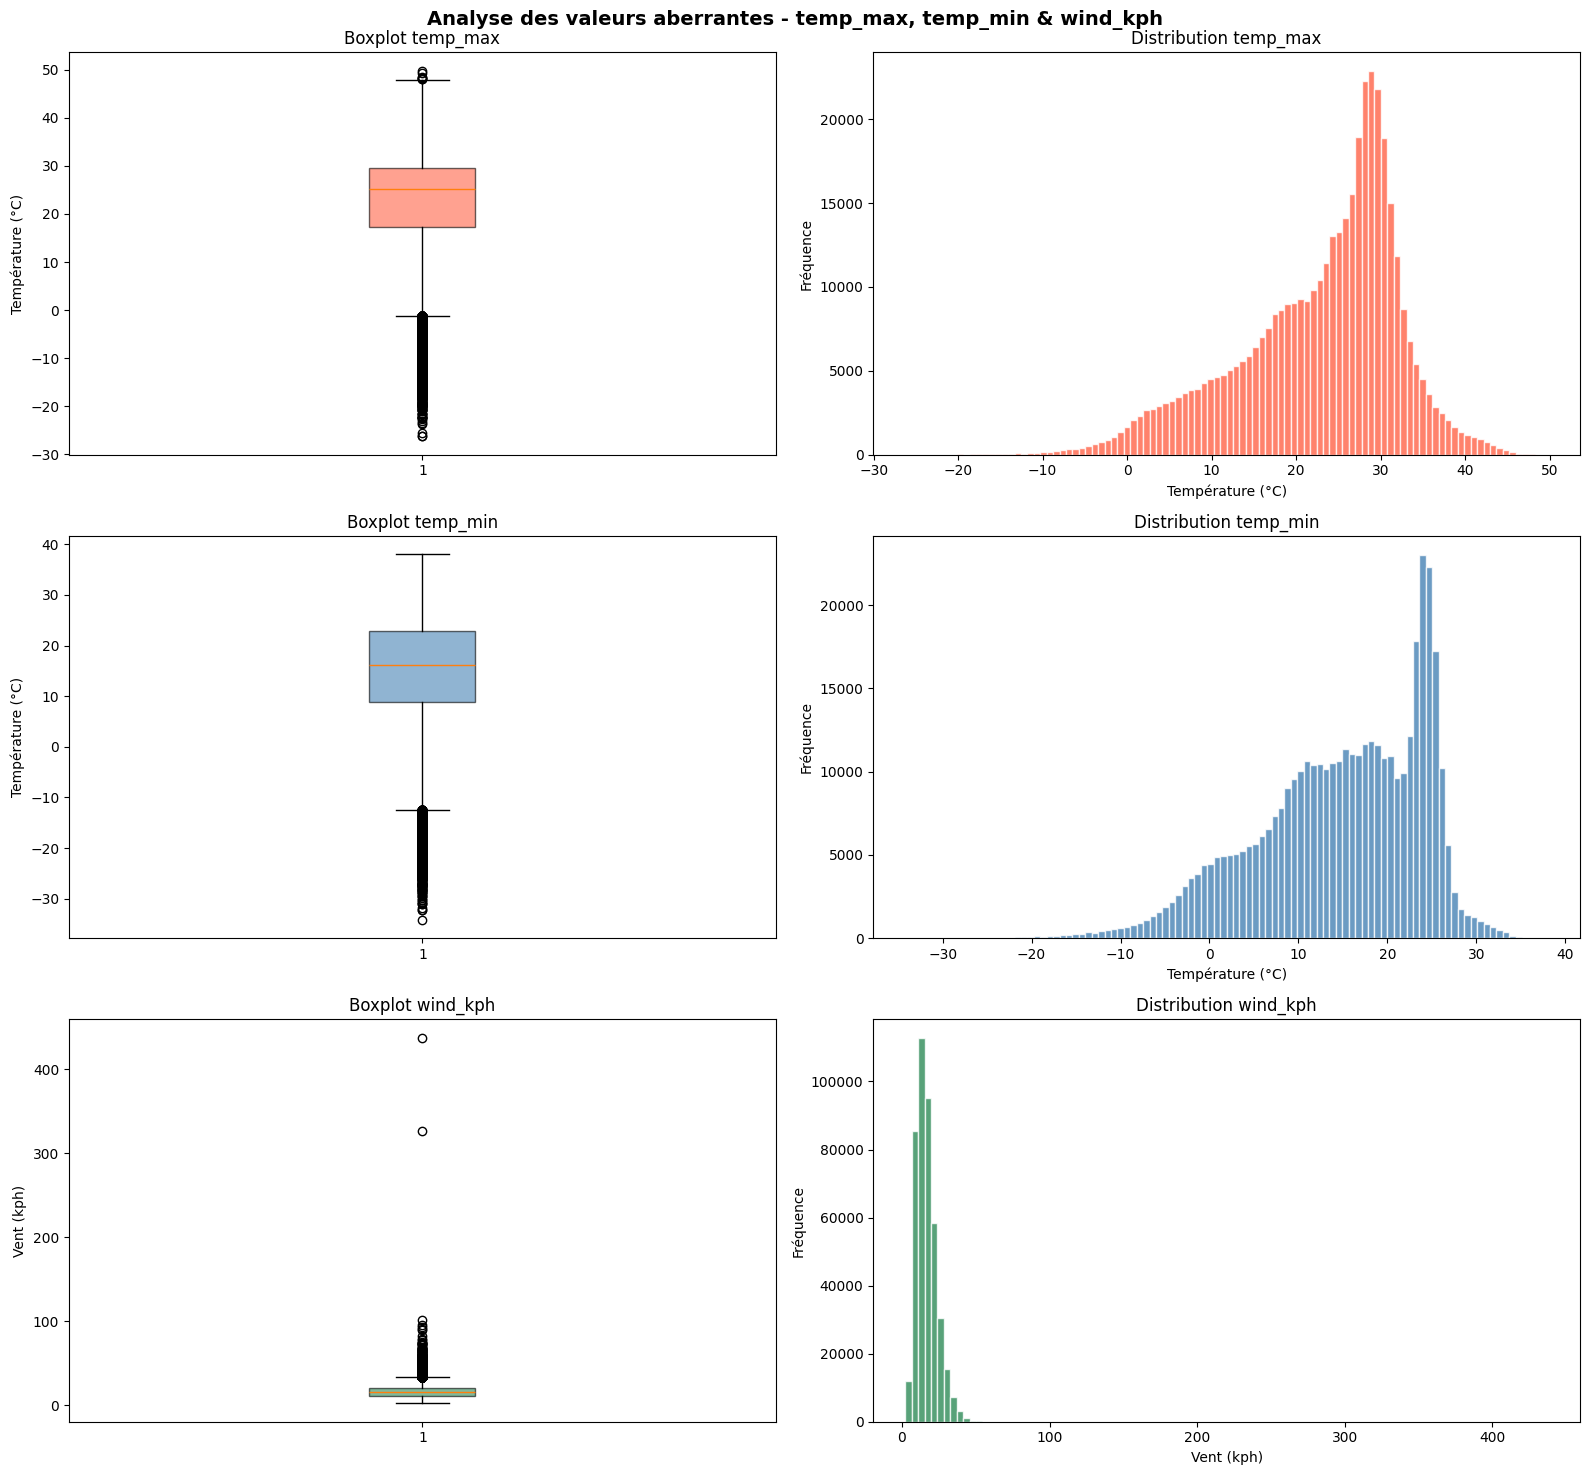

In [ ]:
# ÉTAPE 4 : Visualisation outliers

fig, axes = plt.subplots(3, 2, figsize=(16, 15))
fig.suptitle('Analyse des valeurs aberrantes - temp_max, temp_min & wind_kph',
             fontsize=14, fontweight='bold')

axes[0, 0].boxplot(df_openmeteo['temp_max'].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='tomato', alpha=0.6))
axes[0, 0].set_title('Boxplot temp_max')
axes[0, 0].set_ylabel('Température (°C)')

axes[0, 1].hist(df_openmeteo['temp_max'].dropna(), bins=100,
                color='tomato', edgecolor='white', alpha=0.8)
axes[0, 1].set_title('Distribution temp_max')
axes[0, 1].set_xlabel('Température (°C)')
axes[0, 1].set_ylabel('Fréquence')

axes[1, 0].boxplot(df_openmeteo['temp_min'].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[1, 0].set_title('Boxplot temp_min')
axes[1, 0].set_ylabel('Température (°C)')

axes[1, 1].hist(df_openmeteo['temp_min'].dropna(), bins=100,
                color='steelblue', edgecolor='white', alpha=0.8)
axes[1, 1].set_title('Distribution temp_min')
axes[1, 1].set_xlabel('Température (°C)')
axes[1, 1].set_ylabel('Fréquence')

axes[2, 0].boxplot(df_openmeteo['wind_kph'].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='seagreen', alpha=0.6))
axes[2, 0].set_title('Boxplot wind_kph')
axes[2, 0].set_ylabel('Vent (kph)')

axes[2, 1].hist(df_openmeteo['wind_kph'].dropna(), bins=100,
                color='seagreen', edgecolor='white', alpha=0.8)
axes[2, 1].set_title('Distribution wind_kph')
axes[2, 1].set_xlabel('Vent (kph)')
axes[2, 1].set_ylabel('Fréquence')

plt.tight_layout()
plt.savefig('figures/02_outliers_openmeteo.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
# ÉTAPE 5 : Suppression outliers (seulement wind_kph)

lignes_avant = len(df_openmeteo)
df_openmeteo = df_openmeteo[df_openmeteo['wind_kph'] <= 150]
print(f"Lignes supprimées (wind_kph > 150) : {lignes_avant - len(df_openmeteo):,}")
print(f"Shape après outliers : {df_openmeteo.shape}")

Lignes supprimées (wind_kph > 150) : 2
Shape après outliers : (421888, 9)


In [ ]:
# ÉTAPE 6 : Normalisation du format de date

print("\n" + "=" * 50)
print("NORMALISATION DATE")
print("=" * 50)
print(f"Format avant : {df_openmeteo['date'].iloc[0]}")
df_openmeteo['date'] = pd.to_datetime(df_openmeteo['date']).dt.normalize()
print(f"Format après : {df_openmeteo['date'].iloc[0]}")

print("\n" + "=" * 50)
print("RÉSUMÉ FINAL df_openmeteo")
print("=" * 50)
print(f"Shape finale  : {df_openmeteo.shape}")
print(f"Colonnes      : {list(df_openmeteo.columns)}")
print(f"\nValeurs manquantes :\n{df_openmeteo.isnull().sum()}")
print(f"\n{df_openmeteo.head()}")


NORMALISATION DATE
Format avant : 2009-12-31 20:00:00
Format après : 2009-12-31 00:00:00

RÉSUMÉ FINAL df_openmeteo
Shape finale  : (421888, 9)
Colonnes      : ['date', 'temp_max', 'temp_min', 'temp_mean', 'heat_index', 'humidity', 'precip_mm', 'wind_kph', 'City_clean']

Valeurs manquantes :
date          0
temp_max      0
temp_min      0
temp_mean     0
heat_index    0
humidity      0
precip_mm     0
wind_kph      0
City_clean    0
dtype: int64

        date   temp_max   temp_min  temp_mean  heat_index   humidity  \
0 2009-12-31  23.437000  13.387000  18.766165   21.969866  73.294762   
1 2010-01-01  21.587000  18.286999  19.786999   18.621010  66.478539   
2 2010-01-02  22.886999  17.386999  19.970331   22.812704  63.113827   
3 2010-01-03  21.937000  16.087000  18.734917   21.845078  71.745125   
4 2010-01-04  21.737000  14.187000  18.026581   21.643240  77.941895   

   precip_mm   wind_kph City_clean  
0        0.3  23.185789  Abu Dhabi  
1        0.5  29.764839  Abu Dhabi  
2   

In [ ]:
# Partie 4 — Vérification matching villes


print("\n" + "=" * 50)
print("VÉRIFICATION MATCHING VILLES")
print("=" * 50)
villes_temp  = set(df_temp['City_clean'].unique())
villes_meteo = set(df_openmeteo['City_clean'].unique())

print(f"Villes df_temp      : {len(villes_temp)}")
print(f"Villes df_openmeteo : {len(villes_meteo)}")
print(f"Villes en commun    : {len(villes_temp & villes_meteo)}")
print(f"Villes non matchées : {len(villes_meteo - villes_temp)}")
if villes_meteo - villes_temp:
    print(f"\nVilles sans match :\n{sorted(villes_meteo - villes_temp)}")


VÉRIFICATION MATCHING VILLES
Villes df_temp      : 321
Villes df_openmeteo : 105
Villes en commun    : 105
Villes non matchées : 0


##Partie 4 — Fusion des deux datasets


In [ ]:

df_merged = df_temp.merge(df_openmeteo, on=['City_clean', 'date'], how='inner')

print("=" * 50)
print("RÉSUMÉ FUSION")
print("=" * 50)
print(f"Shape df_temp      : {df_temp.shape}")
print(f"Shape df_openmeteo : {df_openmeteo.shape}")
print(f"Shape df_merged    : {df_merged.shape}")
print(f"\nColonnes : {list(df_merged.columns)}")
print(f"\nValeurs manquantes :\n{df_merged.isnull().sum()}")
print(f"\nPériode couverte   : {df_merged['date'].min()} → {df_merged['date'].max()}")
print(f"Nombre de villes   : {df_merged['City_clean'].nunique()}")
print(f"Nombre de régions  : {df_merged['Region'].nunique()}")
print(f"\n{df_merged.head()}")

RÉSUMÉ FUSION
Shape df_temp      : (2806237, 5)
Shape df_openmeteo : (421888, 9)
Shape df_merged    : (343579, 12)

Colonnes : ['Region', 'Country', 'AvgTemperature_C', 'date', 'City_clean', 'temp_max', 'temp_min', 'temp_mean', 'heat_index', 'humidity', 'precip_mm', 'wind_kph']

Valeurs manquantes :
Region              0
Country             0
AvgTemperature_C    0
date                0
City_clean          0
temp_max            0
temp_min            0
temp_mean           0
heat_index          0
humidity            0
precip_mm           0
wind_kph            0
dtype: int64

Période couverte   : 2009-12-31 00:00:00 → 2020-05-13 00:00:00
Nombre de villes   : 101
Nombre de régions  : 7

   Region  Country  AvgTemperature_C       date City_clean   temp_max  \
0  Africa  Algeria         13.833333 2009-12-31    Algiers  15.255500   
1  Africa  Algeria         15.055556 2010-01-01    Algiers  15.105500   
2  Africa  Algeria         13.111111 2010-01-02    Algiers  16.805500   
3  Africa  Algeri

##Partie 5 — Sauvegarde du dataset final

In [ ]:

output_path = "data/processed/heatwave_merged.parquet"
df_merged.to_parquet(output_path, index=False)

print("=" * 50)
print("SAUVEGARDE")
print("=" * 50)
print(f"Dataset sauvegardé : {output_path}")
print(f"   Shape             : {df_merged.shape}")
print(f"   Taille fichier    : {os.path.getsize(output_path) / 1024 / 1024:.2f} MB")

SAUVEGARDE
✅ Dataset sauvegardé : data/processed/heatwave_merged.parquet
   Shape             : (343579, 12)
   Taille fichier    : 8.67 MB
